# Project Deliverable 1: Data Collection, Cleaning, and Exploration

**Project:** Advanced Data Mining for Data-Driven Insights and Predictive Modeling

## Dataset Selection and Justification

The selected dataset is the UCI Red Wine Quality dataset. It contains 1,599 records and 12 attributes. It is appropriate for the project because the `quality` variable can support regression and classification, while the numeric chemical variables can support clustering and pattern discovery.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SCREENSHOTS = Path('screenshots')
SCREENSHOTS.mkdir(exist_ok=True)
wine = pd.read_csv('data/winequality-red.csv', sep=';')
print('Dataset shape:', wine.shape)
wine.head()

Dataset shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Structure Inspection

In [2]:
wine.info()
wine.describe().round(3)

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


## Data Cleaning

In [3]:
cleaning_report = {}
cleaning_report['initial_rows'] = len(wine)
cleaning_report['initial_columns'] = wine.shape[1]
cleaning_report['missing_values'] = int(wine.isna().sum().sum())
cleaning_report['duplicate_rows'] = int(wine.duplicated().sum())
print(cleaning_report)

wine_clean = wine.copy()
if wine_clean.isna().sum().sum() > 0:
    wine_clean = wine_clean.fillna(wine_clean.median(numeric_only=True))
wine_clean = wine_clean.drop_duplicates().reset_index(drop=True)
print('Shape after duplicate removal and missing-value check:', wine_clean.shape)

{'initial_rows': 1599, 'initial_columns': 12, 'missing_values': 0, 'duplicate_rows': 240}
Shape after duplicate removal and missing-value check: (1359, 12)


In [4]:
numeric_cols = wine_clean.select_dtypes(include='number').columns.tolist()
outlier_counts = {}
for col in numeric_cols:
    q1, q3 = wine_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[col] = int(((wine_clean[col] < lower) | (wine_clean[col] > upper)).sum())
pd.Series(outlier_counts).sort_values(ascending=False)

residual sugar          126
chlorides                87
sulphates                55
total sulfur dioxide     45
fixed acidity            41
density                  35
pH                       28
quality                  27
free sulfur dioxide      26
volatile acidity         19
alcohol                  12
citric acid               1
dtype: int64

In [ ]:
wine_model_ready = wine_clean.copy()
for col in ['residual sugar', 'chlorides', 'total sulfur dioxide', 'sulphates']:
    q1, q3 = wine_model_ready[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    wine_model_ready[col] = wine_model_ready[col].clip(lower, upper)

print('Cleaned/model-ready shape:', wine_model_ready.shape)
wine_model_ready.head()

Cleaned/model-ready shape: (1359, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


## Exploratory Data Analysis

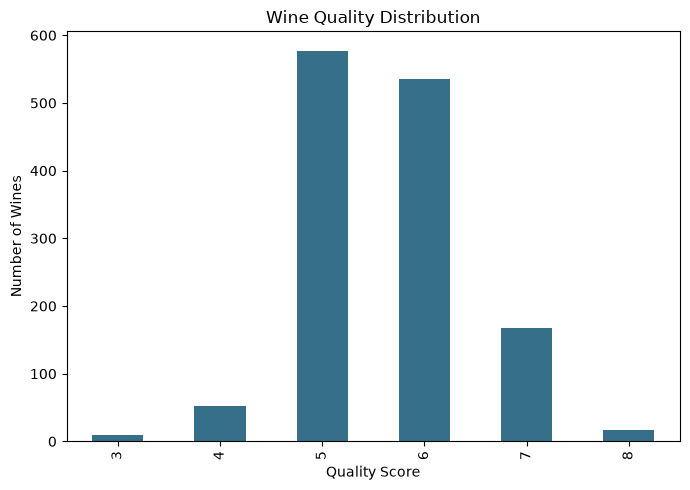

In [6]:
plt.figure(figsize=(7,5))
wine_model_ready['quality'].value_counts().sort_index().plot(kind='bar', color='#356f8a')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'project_quality_distribution.png', dpi=160)
plt.show()

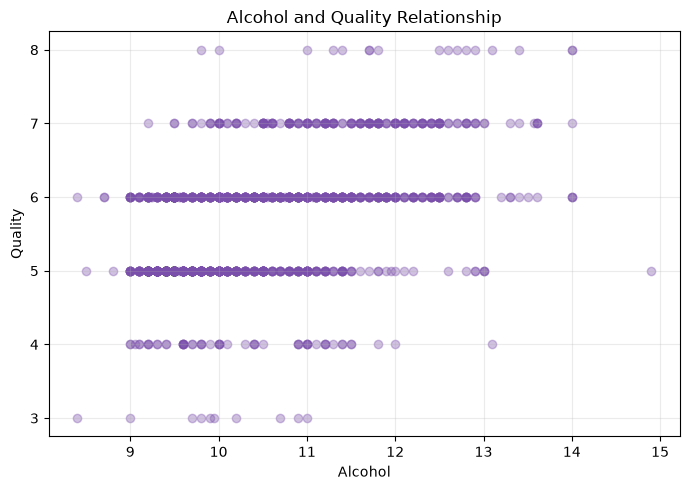

In [7]:
plt.figure(figsize=(7,5))
plt.scatter(wine_model_ready['alcohol'], wine_model_ready['quality'], alpha=0.35, color='#7a4eab')
plt.title('Alcohol and Quality Relationship')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'project_alcohol_quality.png', dpi=160)
plt.show()

In [8]:
corr = wine_model_ready.corr(numeric_only=True)
quality_corr = corr['quality'].sort_values(ascending=False).round(3)
quality_corr

quality                 1.000
alcohol                 0.480
sulphates               0.331
citric acid             0.228
fixed acidity           0.119
residual sugar          0.019
free sulfur dioxide    -0.050
pH                     -0.055
density                -0.184
chlorides              -0.194
total sulfur dioxide   -0.197
volatile acidity       -0.395
Name: quality, dtype: float64

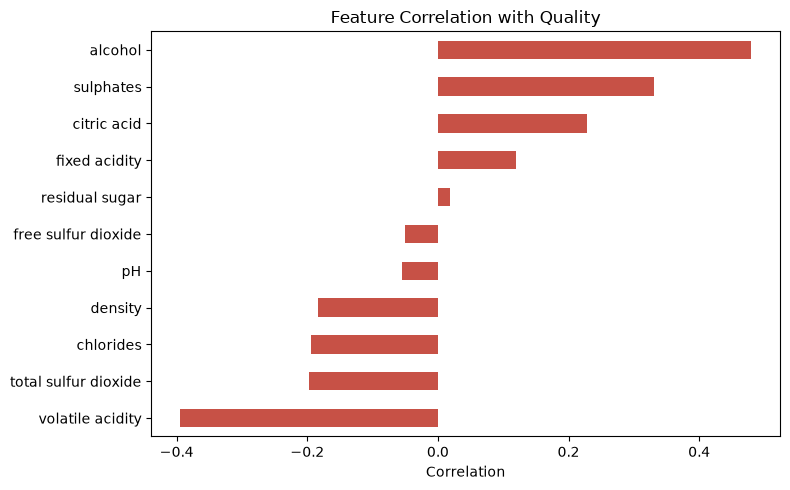

In [9]:
plt.figure(figsize=(8,5))
quality_corr.drop('quality').sort_values().plot(kind='barh', color='#c75146')
plt.title('Feature Correlation with Quality')
plt.xlabel('Correlation')
plt.tight_layout()
plt.savefig(SCREENSHOTS / 'project_quality_correlations.png', dpi=160)
plt.show()

## EDA Insights and Future Modeling Guidance

The quality ratings are concentrated around 5 and 6. Alcohol has the strongest positive relationship with quality, while volatile acidity has a notable negative relationship. These relationships suggest that  regression and classification models should preserve alcohol, volatile acidity, sulphates, citric acid, and density as candidate predictors. Outlier handling is also important because variables such as chlorides and residual sugar include extreme observations that could distort model estimates.

In [10]:
wine_model_ready.to_csv('data/winequality-red-cleaned-project-d1.csv', index=False)
print('Saved cleaned project dataset.')

Saved cleaned project dataset.
